# Laboratorio 14 — Bagging y bosques aleatorios: los hiperparámetros y las dos importancias

Un árbol completo tiene poco sesgo y mucha varianza: sobre dos remuestras del mismo
conjunto crece dos árboles distintos que se equivocan en observaciones distintas.
**Bagging** convierte esa inestabilidad en un recurso, el **error out-of-bag** lo valida
sin apartar datos, y el **bosque aleatorio** agrega un hiperparámetro más. Este
laboratorio explora, con `scikit-learn`, qué hiperparámetros de esa familia hay que ajustar
y cuáles no, y termina en la pregunta que toda medida de importancia obliga a hacerse.

Las preguntas que se responden son dos:

> De los hiperparámetros de un ensamble por bagging —el número de árboles, el tamaño de
> cada árbol, los candidatos por split, la forma de remuestrear—, ¿cuáles cambian el error
> y cuáles no, y con qué evidencia se decide sin un conjunto de validación aparte?
>
> De las dos importancias que devuelve un bosque, ¿cuál dice algo del problema y cuál
> solo del bosque?

Los modelos son `BaggingClassifier` y `RandomForestClassifier`; el árbol base es
`DecisionTreeClassifier` completo, sin poda. Lo que se escribe son cuatro cosas: una
función de barrido sobre un hiperparámetro con el error out-of-bag, la traducción de las
variantes del remuestreo a parámetros de la biblioteca, una grilla ajustada por
out-of-bag para compararla con `GridSearchCV`, y la importancia por permutación, que es la
única función que se implementa desde cero.

Contra qué se verifica, en orden:

1. El barrido, contra un bosque ajustado a mano con los mismos parámetros y la misma
   semilla: igualdad exacta.
2. Las variantes del remuestreo, contra lo que `scikit-learn` guarda de cada miembro
   (`estimators_samples_`, `estimators_features_`): cuántas filas distintas y cuántas
   columnas vio cada árbol.
3. La grilla por out-of-bag, contra el reajuste de su mejor configuración.
4. La importancia por permutación, contra `permutation_importance`, dentro de su desvío
   entre repeticiones; y las dos importancias, contra **el reajuste del bosque sin el
   feature**, la única medida que responde a la pregunta.

Las celdas que contienen `raise NotImplementedError()` deben completarse; el resto es
andamiaje y se ejecuta sin modificar.

## 0. Preparación

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (GridSearchCV, ParameterGrid, StratifiedKFold,
                                     cross_val_score, train_test_split)
from sklearn.tree import DecisionTreeClassifier

SEMILLA = 42
B = 200                # miembros del ensamble, salvo donde el propio B es lo que se explora

# con muy pocos arboles, alguna observacion no queda fuera de ninguno y scikit-learn avisa;
# es el fenomeno que la seccion 2 mide, y el aviso se silencia para no repetirlo 200 veces
warnings.filterwarnings("ignore", message="Some inputs do not have OOB scores")

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

AZUL, TURQUESA, NARANJA = "#19326E", "#50ACB0", "#CD742A"
VIOLETA, OLIVA, GRIS = "#A3477F", "#89A943", "#8A8A8A"

### El caso

**Inspección de máquinas**, el mismo conjunto del laboratorio del árbol: $1200$ máquinas
de una flota industrial, tres features numéricos, cinco categóricos y la respuesta binaria
`requiere_inspeccion`. La regla generadora es un árbol de seis hojas con el $8\ \%$ de las
etiquetas invertido: **el error irreducible es $0{,}08$**, y ningún modelo baja de ahí.

`DecisionTreeClassifier` no parte features categóricos de forma nativa, de modo que acá se
codifican con one-hot encoding. La consecuencia sobre las reglas ya se midió en el
laboratorio del árbol; en este, importa por otra razón: los $32$ features que resultan
son el $p$ sobre el que el bosque sortea sus candidatos.

In [3]:
#@title Carga del conjunto de datos (ejecutar sin modificar) { display-mode: "form" }
CANDIDATAS = [Path("data/inspeccion_maquinas.csv"),
              Path("../../data/inspeccion_maquinas.csv"),
              Path("inspeccion_maquinas.csv")]

ruta = next((c for c in CANDIDATAS if c.exists()), None)
if ruta is None:                                   # plan B: subir el archivo en Colab
    from google.colab import files                 # type: ignore
    files.upload()
    ruta = Path("inspeccion_maquinas.csv")

datos = pd.read_csv(ruta)
print(f"origen: {ruta}")

NUMERICOS = ["antiguedad_anios", "uso_semanal_h", "temperatura_op_c"]
CATEGORICOS = ["material", "planta", "turno", "lote", "proveedor"]
RESPUESTA = "requiere_inspeccion"


def codificar(tabla: pd.DataFrame, numericos: list[str], categoricos: list[str]) -> pd.DataFrame:
    """Matriz de diseño: los numericos tal cual y una columna indicadora por nivel."""
    return pd.get_dummies(tabla[numericos + categoricos], columns=categoricos, dtype=float)


X_todo = codificar(datos, NUMERICOS, CATEGORICOS)
y_todo = datos[RESPUESTA].to_numpy()

X_ajuste, X_prueba, y_ajuste, y_prueba = train_test_split(
    X_todo, y_todo, test_size=0.30, random_state=SEMILLA, stratify=y_todo)
X_ajuste = X_ajuste.reset_index(drop=True)
X_prueba = X_prueba.reset_index(drop=True)
n, p = X_ajuste.shape

print(f"n = {len(y_todo)}   ajuste = {n}   prueba = {len(y_prueba)}   p (one-hot) = {p}")
print(f"prevalencia = {y_todo.mean():.4f}   error irreducible = 0.08")

origen: inspeccion_maquinas.csv
n = 1200   ajuste = 840   prueba = 360   p (one-hot) = 32
prevalencia = 0.4425   error irreducible = 0.08


### El punto de partida: un árbol completo, y su inestabilidad

Un solo árbol, crecido hasta hojas puras, sobre el conjunto de ajuste. Después, el mismo
procedimiento sobre $50$ remuestras con reposición: el error de cada árbol y **el
desacuerdo entre dos de ellos**, la fracción del conjunto de prueba sobre la que
predicen clases distintas.

In [4]:
def arbol_completo(semilla: int = 0) -> DecisionTreeClassifier:
    """El procedimiento base de todo el laboratorio: sin poda, hojas puras."""
    return DecisionTreeClassifier(random_state=semilla)


def error(pred: np.ndarray, y: np.ndarray) -> float:
    return float((pred != y).mean())


uno = arbol_completo().fit(X_ajuste, y_ajuste)
err_uno = error(uno.predict(X_prueba), y_prueba)

rng = np.random.default_rng(SEMILLA)
predicciones = []
for b in range(50):
    idx = rng.integers(0, n, n)
    t = arbol_completo(b).fit(X_ajuste.iloc[idx], y_ajuste[idx])
    predicciones.append(t.predict(X_prueba))
predicciones = np.array(predicciones)

errores = [error(pr, y_prueba) for pr in predicciones]
desacuerdos = [(predicciones[i] != predicciones[i + 1]).mean() for i in range(0, 48, 2)]

print(f"un arbol completo, error de prueba          : {err_uno:.4f}")
print(f"arboles sobre remuestras, error medio        : {np.mean(errores):.4f}  (desvio {np.std(errores):.4f})")
print(f"desacuerdo entre dos arboles, media          : {np.mean(desacuerdos):.4f}")
print(f"error irreducible                            : 0.0800")

un arbol completo, error de prueba          : 0.1583
arboles sobre remuestras, error medio        : 0.1604  (desvio 0.0175)
desacuerdo entre dos arboles, media          : 0.1677
error irreducible                            : 0.0800


### Para analizar

Dos árboles ajustados sobre remuestras del mismo conjunto tienen casi el mismo error, y
**discrepan entre sí en una fracción del conjunto de prueba tan grande como ese error**.

¿Qué dice ese desacuerdo sobre *dónde* se equivoca cada árbol, y por qué es exactamente
la situación en la que promediar puede ayudar?

**Respuesta:**

El desacuerdo muestra que los árboles no se equivocan siempre sobre las mismas
observaciones: tienen errores parecidos en cantidad, pero distintos en ubicación. Esto
indica alta varianza frente al remuestreo. Al promediar o votar, los errores que no están
perfectamente correlacionados tienden a cancelarse, mientras que la señal común se
refuerza. Por eso bagging ayuda justamente cuando los modelos individuales son
inestables y sus errores no coinciden por completo.


---

# 1. Bagging con `scikit-learn`, y el error out-of-bag

`BaggingClassifier` implementa el pseudocódigo BAGGING de las notas: $B$ muestras
bootstrap, un ajuste del estimador base sobre cada una, y el voto. Con `oob_score=True`
calcula además el **error out-of-bag**: cada observación es predicha solo por los árboles
que no la vieron, y `oob_score_` es la exactitud de esas predicciones. Lo que guarda de
cada miembro —`estimators_samples_`, los índices de su muestra— permite verificar el
$63{,}2\ \%$ sin implementar nada.

In [5]:
bag = BaggingClassifier(arbol_completo(), n_estimators=B, oob_score=True,
                        random_state=SEMILLA, n_jobs=-1).fit(X_ajuste, y_ajuste)

err_bag = error(bag.predict(X_prueba), y_prueba)
err_oob = 1.0 - bag.oob_score_

distintas = np.array([len(np.unique(m)) for m in bag.estimators_samples_])
fuera = 1.0 - distintas / n

print(f"un arbol completo        : {err_uno:.4f}")
print(f"bagging de {B} arboles   : {err_bag:.4f}")
print(f"error out-of-bag         : {err_oob:.4f}")
print(f"error irreducible        : 0.0800")
print(f"\nfraccion de observaciones fuera de cada muestra: media {fuera.mean():.4f}  "
      f"(entre {fuera.min():.4f} y {fuera.max():.4f});  e^-1 = {np.exp(-1):.4f}")

un arbol completo        : 0.1583
bagging de 200 arboles   : 0.0778
error out-of-bag         : 0.0869
error irreducible        : 0.0800

fraccion de observaciones fuera de cada muestra: media 0.3667  (entre 0.3464 y 0.3940);  e^-1 = 0.3679


### Out-of-bag contra validación cruzada

El error out-of-bag salió de los $200$ árboles que ya estaban ajustados. La validación
cruzada en cinco folds, sobre el mismo conjunto de ajuste, requiere ajustar cinco
ensambles más. Los tres números —out-of-bag, validación cruzada, prueba— estiman lo mismo.

In [6]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
exactitud_cv = cross_val_score(BaggingClassifier(arbol_completo(), n_estimators=B, random_state=SEMILLA, n_jobs=-1),
                               X_ajuste, y_ajuste, cv=folds)
err_cv = 1.0 - exactitud_cv.mean()

resolucion_ajuste = np.sqrt(0.08 * 0.92 / n)
resolucion_prueba = np.sqrt(0.08 * 0.92 / len(y_prueba))

print(f"out-of-bag          : {err_oob:.4f}   con {B} arboles ajustados          (+/- {resolucion_ajuste:.4f})")
print(f"validacion cruzada  : {err_cv:.4f}   con {5 * B} + {B} arboles ajustados   (+/- {resolucion_ajuste:.4f}, desvio entre folds {exactitud_cv.std():.4f})")
print(f"prueba              : {err_bag:.4f}   con {B} arboles ajustados          (+/- {resolucion_prueba:.4f})")

out-of-bag          : 0.0869   con 200 arboles ajustados          (+/- 0.0094)
validacion cruzada  : 0.0845   con 1000 + 200 arboles ajustados   (+/- 0.0094, desvio entre folds 0.0170)
prueba              : 0.0778   con 200 arboles ajustados          (+/- 0.0143)


### Para analizar

Los tres números coinciden dentro de su resolución. Si la validación cruzada no agrega
información y cuesta seis veces más árboles, ¿para qué se la mantiene en la caja de
herramientas? Nombrar una situación de este mismo laboratorio en la que el error
out-of-bag **no** sirve.

**Respuesta:** La validación cruzada sigue siendo necesaria para modelos que no generan muestras
bootstrap y, por lo tanto, no tienen observaciones out-of-bag. En este mismo laboratorio,
un `DecisionTreeClassifier` individual no tiene error OOB, por lo que para elegir
`min_samples_leaf` se lo evalúa mediante validación cruzada. Lo mismo ocurre con pasting
(`bootstrap=False`) y, en general, cuando se quieren comparar de manera uniforme modelos
que no admiten OOB.



### Ejercicio 1: el barrido de un hiperparámetro

Todo lo que sigue repite una operación: fijar los demás hiperparámetros, recorrer los
valores de uno, y anotar el error out-of-bag y el de prueba de cada bosque. Se implementa
una vez. `RandomForestClassifier` con `max_features=None` **es** bagging de árboles
completos —todos los features compiten en cada split—, y es el modelo que se usa en los
barridos: tiene `oob_score`, corre en paralelo, y sus otros hiperparámetros son los del
árbol base.

In [7]:
def barrido(parametro: str, valores: list, **fijos) -> pd.DataFrame:
    """Error out-of-bag y de prueba de un bosque, para cada valor de un hiperparametro."""
    filas = []

    for valor in valores:
        parametros = {
            "n_estimators": B,
            "max_features": None,
        }
        parametros.update(fijos)
        parametros[parametro] = valor

        bosque = RandomForestClassifier(
            **parametros,
            oob_score=True,
            random_state=SEMILLA,
            n_jobs=-1,
        ).fit(X_ajuste, y_ajuste)

        filas.append({
            "oob": 1.0 - bosque.oob_score_,
            "prueba": error(bosque.predict(X_prueba), y_prueba),
        })

    return pd.DataFrame(
        filas,
        index=pd.Index(valores, name=parametro),
    )

In [8]:
# VERIFICACIÓN — el barrido reproduce, exactamente, un bosque ajustado a mano con la misma semilla
referencia = RandomForestClassifier(n_estimators=B, max_features=None, oob_score=True,
                                    random_state=SEMILLA, n_jobs=-1).fit(X_ajuste, y_ajuste)
esperado_oob = 1.0 - referencia.oob_score_
esperado_prueba = error(referencia.predict(X_prueba), y_prueba)

tabla = barrido("n_estimators", [B])
assert list(tabla.columns) == ["oob", "prueba"], "las columnas deben ser 'oob' y 'prueba'"
assert list(tabla.index) == [B], "el indice debe ser la lista de valores"
assert np.isclose(tabla.loc[B, "oob"], esperado_oob, atol=1e-12), "el error out-of-bag no coincide"
assert np.isclose(tabla.loc[B, "prueba"], esperado_prueba, atol=1e-12), "el error de prueba no coincide"

tabla2 = barrido("min_samples_leaf", [1, 5], n_estimators=50)
assert tabla2.shape == (2, 2) and tabla2.index.name == "min_samples_leaf", "los fijos no se aplican o el indice esta mal"

print(f"bagging de {B} arboles, como RandomForestClassifier(max_features=None): "
      f"out-of-bag {esperado_oob:.4f}, prueba {esperado_prueba:.4f}")
print("\nVERIFICACIÓN SUPERADA: el barrido ajusta exactamente el bosque que dice ajustar.")

bagging de 200 arboles, como RandomForestClassifier(max_features=None): out-of-bag 0.0869, prueba 0.0778

VERIFICACIÓN SUPERADA: el barrido ajusta exactamente el bosque que dice ajustar.


---

# 2. Los hiperparámetros del ensamble, uno por uno

Tres barridos con la función del ejercicio 1. En cada uno, la pregunta es la misma: **¿este
hiperparámetro cambia el error, y en qué dirección?** La evidencia es la curva out-of-bag,
que no costó ningún conjunto de validación, y la de prueba la confirma.

### El número de árboles, $B$

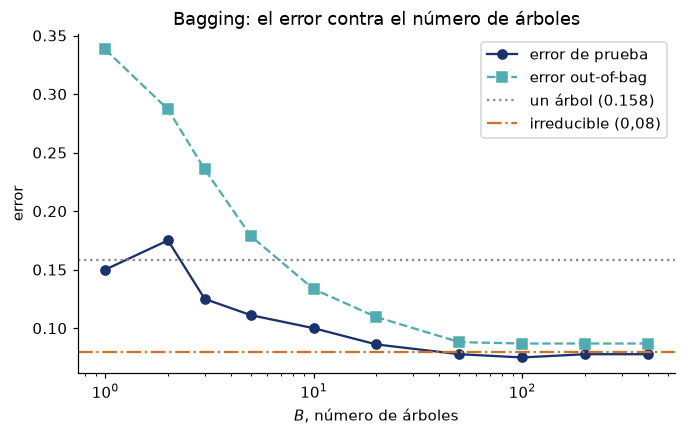

                 oob  prueba
n_estimators                
1             0.3381  0.1500
2             0.2869  0.1750
3             0.2357  0.1250
5             0.1786  0.1111
10            0.1333  0.1000
20            0.1095  0.0861
50            0.0881  0.0778
100           0.0869  0.0750
200           0.0869  0.0778
400           0.0869  0.0778


In [9]:
valores_B = [1, 2, 3, 5, 10, 20, 50, 100, 200, 400]
curva_B = barrido("n_estimators", valores_B)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curva_B.index, curva_B["prueba"], "o-", color=AZUL, label="error de prueba")
ax.plot(curva_B.index, curva_B["oob"], "s--", color=TURQUESA, label="error out-of-bag")
ax.axhline(err_uno, color=GRIS, ls=":", label=f"un árbol ({err_uno:.3f})")
ax.axhline(0.08, color=NARANJA, ls="-.", label="irreducible (0,08)")
ax.set_xscale("log")
ax.set_xlabel("$B$, número de árboles")
ax.set_ylabel("error")
ax.set_title("Bagging: el error contra el número de árboles")
ax.legend()
plt.show()

print(curva_B.round(4).to_string())

### Para analizar

1. A partir de cierto $B$ la curva de prueba deja de moverse, y **nunca vuelve a subir**.
   ¿Qué distingue a $B$ de los demás hiperparámetros de un modelo, y cómo se lo fija en la
   práctica?
2. Con $B$ chico, el error out-of-bag queda muy por encima del error de prueba, y con $B$
   grande los dos se juntan. Cada observación es predicha por unos $B/e$ árboles: ¿cuántos
   son con $B=5$, y qué clase de ensamble es ese?
3. Cuando la curva se aplana, ¿qué término de la varianza del promedio,
   $\rho\sigma_f^2+\frac{1-\rho}{B}\sigma_f^2$, quedó, y qué haría falta para bajarlo?

**Respuesta:**

1. A diferencia de parámetros como la profundidad o el tamaño mínimo de hoja, aumentar
   $B$ no aumenta la complejidad de cada árbol ni introduce más sobreajuste: solo reduce
   la parte de la varianza debida a usar un número finito de miembros. En la práctica se
   aumenta $B$ hasta que el error OOB se estabiliza y luego se elige según el costo de
   cómputo. En estos resultados la curva ya está prácticamente estable desde
   $B\approx50$--$100$.
2. Con $B=5$, cada observación recibe en promedio $B/e\approx1{,}84$ predicciones OOB, es
   decir, apenas uno o dos árboles. Ese no es un ensamble estable: una sola predicción
   equivocada puede dominar el resultado OOB, y algunas observaciones incluso pueden no
   quedar fuera de ninguna muestra.
3. Cuando la curva se aplana, el término $\frac{1-\rho}{B}\sigma_f^2$ ya es casi cero y
   queda $\rho\sigma_f^2$, la varianza asociada a la correlación entre los árboles. Para
   bajarla no alcanza con agregar árboles: hay que reducir $\rho$, por ejemplo sorteando
   candidatos en cada split mediante `max_features`, sin elevar demasiado el sesgo.


### El tamaño del árbol: `min_samples_leaf`

Un árbol solo se poda, o se le fija un tamaño mínimo de hoja, porque completo sobreajusta.
La pregunta es si el árbol **promediado** necesita lo mismo. El barrido corre dos veces:
sobre el árbol solo, evaluado por validación cruzada porque no tiene out-of-bag, y sobre el
bosque.

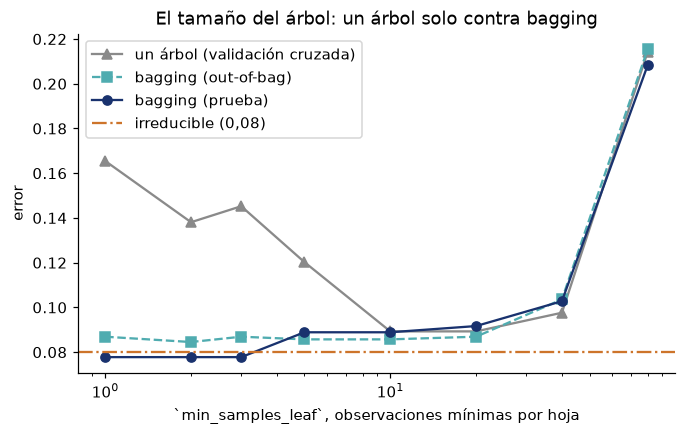

    árbol (cv)     oob  prueba
1       0.1655  0.0869  0.0778
2       0.1381  0.0845  0.0778
3       0.1452  0.0869  0.0778
5       0.1202  0.0857  0.0889
10      0.0893  0.0857  0.0889
20      0.0893  0.0869  0.0917
40      0.0976  0.1036  0.1028
80      0.2143  0.2155  0.2083


In [10]:
valores_hoja = [1, 2, 3, 5, 10, 20, 40, 80]

curva_hoja_arbol = pd.Series(
    [1.0 - cross_val_score(DecisionTreeClassifier(min_samples_leaf=h, random_state=0),
                           X_ajuste, y_ajuste, cv=folds).mean() for h in valores_hoja],
    index=valores_hoja, name="árbol solo, validación cruzada")
curva_hoja = barrido("min_samples_leaf", valores_hoja)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(valores_hoja, curva_hoja_arbol, "^-", color=GRIS, label="un árbol (validación cruzada)")
ax.plot(valores_hoja, curva_hoja["oob"], "s--", color=TURQUESA, label="bagging (out-of-bag)")
ax.plot(valores_hoja, curva_hoja["prueba"], "o-", color=AZUL, label="bagging (prueba)")
ax.axhline(0.08, color=NARANJA, ls="-.", label="irreducible (0,08)")
ax.set_xscale("log")
ax.set_xlabel("`min_samples_leaf`, observaciones mínimas por hoja")
ax.set_ylabel("error")
ax.set_title("El tamaño del árbol: un árbol solo contra bagging")
ax.legend()
plt.show()

print(pd.concat([curva_hoja_arbol.rename("árbol (cv)"), curva_hoja], axis=1).round(4).to_string())

### DECIDE

¿Qué valor de `min_samples_leaf` corresponde para el árbol solo, y cuál para el bosque?
Responder con la resolución, $\pm0{,}010$ sobre el conjunto de ajuste, y explicar:

1. Por qué el árbol solo mejora tanto al agrandar la hoja, y el bosque no mejora nada.
2. Qué pasa en el bosque con hojas de $80$ observaciones, y qué término del error subió.
3. Por qué, entonces, las notas dicen que los miembros de un bagging se crecen completos,
   sin poda.

**Respuesta:**

Para el árbol solo elegiría `min_samples_leaf=10` (20 empata): su error de validación es
`0.0893`, frente a `0.1655` con hojas de tamaño 1. Para el bosque elegiría
`min_samples_leaf=1`, es decir, árboles completos. Entre 1 y 20 las diferencias OOB son
menores que la resolución $\pm0{,}010$, así que no hay evidencia de una mejora por podar;
se conserva 1 porque evita introducir sesgo.

1. El árbol individual completo tiene mucha varianza y memoriza particularidades del
   ajuste; agrandar las hojas lo regulariza y reduce esa varianza. En bagging, la votación
   ya reduce la varianza de los árboles completos, por lo que podarlos no aporta una
   mejora adicional.
2. Con hojas de 80 observaciones el bosque queda demasiado rígido: el error OOB sube a
   `0.2155` y el de prueba a `0.2083`. Aumentó el sesgo porque los árboles ya no pueden
   representar las particiones necesarias.
3. Por eso los miembros se crecen completos: se conserva su bajo sesgo y su alta
   varianza se reduce mediante el promedio. Podarlos cambiaría varianza por sesgo cuando
   el ensamble ya se ocupa de la primera.



### Los candidatos por split: `max_features`, el $m_{\text{try}}$ de las notas

El bosque aleatorio es bagging de árboles completos en los que, **en cada nodo**, solo
$m_{\text{try}}$ features sorteados al azar compiten por el split. Con $m_{\text{try}}=p$
es bagging. Bajar $m_{\text{try}}$ descorrelaciona los árboles —baja $\rho$— y empeora cada
árbol —sube el sesgo—; dónde conviene ponerlo lo decide el problema.

Sobre este problema, $p=32$ features one-hot, de los que **pocos informan**: tres
numéricos y las columnas indicadoras de `material` y `planta`.

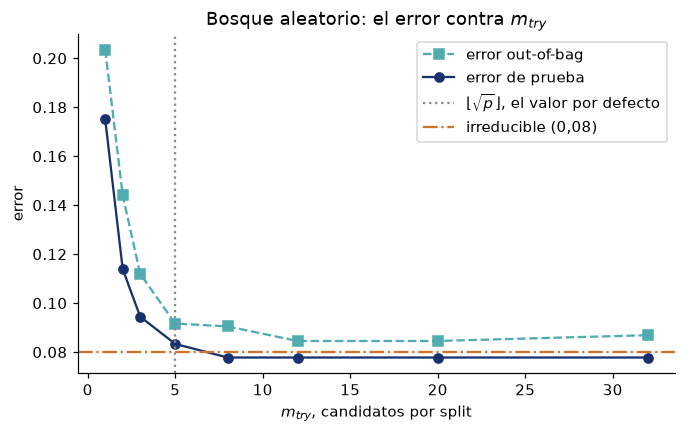

       oob  prueba
1   0.2036  0.1750
2   0.1440  0.1139
3   0.1119  0.0944
5   0.0917  0.0833
8   0.0905  0.0778
12  0.0845  0.0778
20  0.0845  0.0778
32  0.0869  0.0778


In [11]:
valores_mtry = [1, 2, 3, 5, 8, 12, 20, None]
curva_mtry = barrido("max_features", valores_mtry)
curva_mtry.index = [p if v is None else v for v in valores_mtry]     # None es "todos": p

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curva_mtry.index, curva_mtry["oob"], "s--", color=TURQUESA, label="error out-of-bag")
ax.plot(curva_mtry.index, curva_mtry["prueba"], "o-", color=AZUL, label="error de prueba")
ax.axvline(int(np.sqrt(p)), color=GRIS, ls=":", label=r"$\lfloor\sqrt{p}\rfloor$, el valor por defecto")
ax.axhline(0.08, color=NARANJA, ls="-.", label="irreducible (0,08)")
ax.set_xlabel("$m_{try}$, candidatos por split")
ax.set_ylabel("error")
ax.set_title("Bosque aleatorio: el error contra $m_{try}$")
ax.legend()
plt.show()

print(curva_mtry.round(4).to_string())

### DECIDE

Sobre este problema, ¿qué valor de $m_{\text{try}}$ se elige, con qué evidencia, y qué
diferencia con el valor por defecto $\lfloor\sqrt p\rfloor$ es real y cuál es empate?

Y, sobre $p$ features de los que $r$ informan, en general:

1. Con $m_{\text{try}}=1$, ¿qué fracción de las raíces parte sobre un feature de ruido, y
   qué hace eso con el sesgo de cada árbol?
2. Con $m_{\text{try}}=p$, ¿qué pasa con la correlación entre los árboles, y por qué acá
   eso **no** es un problema?
3. ¿Qué tendría que cambiar en el problema para que el mejor $m_{\text{try}}$ fuera chico?

**Respuesta:**

Elegiría $m_{\text{try}}=10$ o 12; en la grilla posterior, 10 obtiene el menor error OOB
(`0.0845`). Los valores entre 8 y 32 tienen el mismo error de prueba (`0.0778`) y sus
diferencias OOB están dentro de $\pm0{,}010$. El valor por defecto
$\lfloor\sqrt{32}\rfloor=5$ da OOB `0.0917` y prueba `0.0833`: numéricamente es algo peor,
pero la diferencia con 10 no supera la resolución, de modo que es un empate estadístico.
La diferencia realmente clara aparece con valores muy chicos, especialmente 1 y 2,
cuyos errores son mucho mayores.

1. Si solo $r$ de los $p$ features informan, con $m_{\text{try}}=1$ una fracción
   $(p-r)/p$ de las raíces recibe un feature de ruido. En este caso es aproximadamente
   $25/32=0{,}781$, lo que produce splits débiles y aumenta el sesgo de cada árbol.
2. Con $m_{\text{try}}=p$ todos los árboles ven los mismos candidatos fuertes y aumenta
   su correlación. Aquí eso no perjudica de forma apreciable porque la señal es fuerte y
   el bagging ya llega aproximadamente al error irreducible; queda muy poca varianza útil
   por reducir.
3. Un $m_{\text{try}}$ chico sería preferible si hubiera muchos features informativos o
   redundantes, de forma que casi todo subconjunto contuviera señal, y si la correlación
   entre árboles fuera una fuente importante del error. Así se podría bajar $\rho$ sin
   aumentar mucho el sesgo.



---

# 3. Las variantes del remuestreo

Bagging remuestrea **filas** con reposición. `BaggingClassifier` permite cambiar cada
pieza de ese sorteo, y cada combinación tiene nombre:

| Variante | Filas | Columnas |
|---|---|---|
| **Bagging** | $n$, con reposición | todas |
| **Pasting** | una fracción de $n$, **sin** reposición | todas |
| **Subespacios aleatorios** | todas | una fracción, sorteada **una vez por árbol** |
| **Patches aleatorios** | $n$, con reposición | una fracción, sorteada una vez por árbol |
| **Bosque aleatorio** | $n$, con reposición | $m_{\text{try}}$, sorteados **en cada split** |

Los parámetros que lo controlan son `bootstrap`, `max_samples`, `max_features` y
`bootstrap_features`; su significado exacto está en la documentación de la clase y
conviene leerla, porque `max_features` **no** significa lo mismo acá que en
`RandomForestClassifier`.

### Ejercicio 2

Completar el diccionario con los parámetros de `BaggingClassifier` que producen cada
variante, con la mitad de las columnas ($16$ de $32$) donde corresponda una fracción, y
$63{,}2\ \%$ de las filas en pasting, de modo que cada árbol vea tantas observaciones
distintas como en bagging. La verificación mira lo que `scikit-learn` guarda de cada
miembro.

In [12]:
# Cada valor es el diccionario de parametros que se pasa a BaggingClassifier(**parametros),
# ademas de estimator, n_estimators, random_state y n_jobs, que pone el andamiaje.
# Parametros disponibles: bootstrap, max_samples, max_features, bootstrap_features.
VARIANTES = {
    "bagging": {
        "bootstrap": True,
        "max_samples": 1.0,
        "max_features": 1.0,
        "bootstrap_features": False,
    },
    "pasting": {
        "bootstrap": False,
        "max_samples": 0.632,
        "max_features": 1.0,
        "bootstrap_features": False,
    },
    "subespacios": {
        "bootstrap": False,
        "max_samples": 1.0,
        "max_features": 0.5,
        "bootstrap_features": False,
    },
    "patches": {
        "bootstrap": True,
        "max_samples": 1.0,
        "max_features": 0.5,
        "bootstrap_features": False,
    },
}

In [13]:
# VERIFICACIÓN — cuantas filas distintas y cuantas columnas vio cada arbol, segun scikit-learn
def ajustar_variante(nombre: str) -> BaggingClassifier:
    return BaggingClassifier(arbol_completo(), n_estimators=B, random_state=SEMILLA, n_jobs=-1,
                             **VARIANTES[nombre]).fit(X_ajuste, y_ajuste)


ajustadas = {nombre: ajustar_variante(nombre) for nombre in VARIANTES}

esperado = {           # (filas distintas por arbol, con repeticion?, columnas por arbol)
    "bagging":     (0.632 * n, True,  p),
    "pasting":     (0.632 * n, False, p),
    "subespacios": (n,         False, p // 2),
    "patches":     (0.632 * n, True,  p // 2),
}
for nombre, modelo in ajustadas.items():
    filas = [len(np.unique(m)) for m in modelo.estimators_samples_]
    repite = any(len(m) > len(np.unique(m)) for m in modelo.estimators_samples_)
    columnas = {len(f) for f in modelo.estimators_features_}
    distintas_esp, repite_esp, columnas_esp = esperado[nombre]
    print(f"{nombre:<12} filas distintas por arbol {np.mean(filas):6.1f}   con repeticion: {str(repite):<5}   columnas por arbol: {columnas}")
    assert abs(np.mean(filas) - distintas_esp) < 0.02 * n, f"{nombre}: cada arbol deberia ver ~{distintas_esp:.0f} filas distintas"
    assert repite == repite_esp, f"{nombre}: la reposicion esta al reves"
    assert columnas == {columnas_esp}, f"{nombre}: cada arbol deberia ver {columnas_esp} columnas"
print("\nVERIFICACIÓN SUPERADA: las cuatro variantes remuestrean lo que dicen remuestrear.")

bagging      filas distintas por arbol  532.0   con repeticion: True    columnas por arbol: {32}
pasting      filas distintas por arbol  530.0   con repeticion: False   columnas por arbol: {32}
subespacios  filas distintas por arbol  840.0   con repeticion: False   columnas por arbol: {16}
patches      filas distintas por arbol  531.5   con repeticion: True    columnas por arbol: {16}

VERIFICACIÓN SUPERADA: las cuatro variantes remuestrean lo que dicen remuestrear.


Con las variantes verificadas, su error, más el del bosque aleatorio —el sorteo **por
split**, con $m_{\text{try}}=\lfloor\sqrt p\rfloor$— y, para la comparación que importa,
el sorteo **por árbol** con la misma cantidad de columnas que el bosque sortea por nodo.

In [14]:
errores_variantes = {nombre: error(m.predict(X_prueba), y_prueba) for nombre, m in ajustadas.items()}

mtry = int(np.sqrt(p))
bosque_sqrt = RandomForestClassifier(n_estimators=B, max_features=mtry, random_state=SEMILLA, n_jobs=-1).fit(X_ajuste, y_ajuste)
errores_variantes[f"bosque, {mtry} por split"] = error(bosque_sqrt.predict(X_prueba), y_prueba)

patches_sqrt = BaggingClassifier(arbol_completo(), n_estimators=B, bootstrap=True, max_features=mtry,
                                 random_state=SEMILLA, n_jobs=-1).fit(X_ajuste, y_ajuste)
errores_variantes[f"patches, {mtry} por árbol"] = error(patches_sqrt.predict(X_prueba), y_prueba)

print(f"{'variante':<24} error de prueba   (resolucion +/- {resolucion_prueba:.3f})")
for nombre, e in errores_variantes.items():
    print(f"{nombre:<24} {e:.4f}")

variante                 error de prueba   (resolucion +/- 0.014)
bagging                  0.0778
pasting                  0.0806
subespacios              0.1167
patches                  0.1000
bosque, 5 por split      0.0833
patches, 5 por árbol     0.2972


### Para analizar

1. Pasting y bagging empatan. ¿Qué dice eso sobre **qué** es lo que hace funcionar al
   ensamble: la reposición, o que los miembros vean datos distintos?
2. Sortear $5$ columnas **por árbol** da un error tres veces mayor que sortear $5$
   **por split**. Con $r\approx7$ columnas informativas de $32$, calcular la probabilidad
   de que un árbol entero se quede sin ninguna, y explicar por qué el sorteo por split no
   tiene ese problema.

**Respuesta:**

1. Bagging (`0.0778`) y pasting (`0.0806`) empatan dentro de la resolución
   $\pm0{,}014$. Esto indica que la reposición no es el ingrediente esencial. Lo que
   importa es que los miembros se ajusten sobre conjuntos de observaciones distintos,
   generen errores parcialmente diferentes y que el voto reduzca su varianza.
2. La probabilidad de que una selección de 5 columnas no contenga ninguna de las 7
   informativas es

   $$
   \frac{\binom{25}{5}}{\binom{32}{5}}\approx0{,}2638.
   $$

   Por lo tanto, aproximadamente el 26,4 % de los árboles de patches queda sin señal
   informativa durante toda su construcción. En un bosque aleatorio el sorteo se repite
   en cada nodo: un nodo puede recibir solo ruido, pero el árbol dispone de nuevas
   oportunidades de incluir señal en los splits siguientes. Por eso sortear 5 columnas
   por árbol da error `0.2972`, mientras sortearlas por split da `0.0833`.


---

# 4. Ajustar varios hiperparámetros a la vez: out-of-bag contra `GridSearchCV`

La herramienta estándar para ajustar hiperparámetros es `GridSearchCV`: cada configuración
de la grilla se evalúa por validación cruzada, y la mejor se reajusta sobre todo el
conjunto. Para un bosque, cada configuración trae su propio error out-of-bag, y la grilla
se puede recorrer **sin ningún pliegue**.

### Ejercicio 3

Implementar la grilla evaluada por out-of-bag. `ParameterGrid` recorre las combinaciones de
un diccionario de listas, como `GridSearchCV`.

In [15]:
def grilla_oob(grilla: dict) -> pd.DataFrame:
    """Error out-of-bag de RandomForestClassifier para cada combinacion de la grilla."""

    filas = []

    for parametros in ParameterGrid(grilla):
        bosque = RandomForestClassifier(
            **parametros,
            oob_score=True,
            random_state=SEMILLA,
            n_jobs=-1,
        ).fit(X_ajuste, y_ajuste)

        filas.append({
            **parametros,
            "oob": 1.0 - bosque.oob_score_,
        })

    return (
        pd.DataFrame(filas)
        .sort_values("oob")
        .reset_index(drop=True)
    )



In [16]:
GRILLA = {"n_estimators": [50, 200],
          "max_features": [2, 5, 10, p],          # p candidatos = todos = bagging
          "min_samples_leaf": [1, 5]}

resultado_oob = grilla_oob(GRILLA)

# VERIFICACIÓN — una fila por combinacion, y la mejor fila se reproduce al reajustarla
assert len(resultado_oob) == len(ParameterGrid(GRILLA)), "falta o sobra alguna combinacion"
assert "oob" in resultado_oob.columns and set(GRILLA) <= set(resultado_oob.columns), "faltan columnas"
assert resultado_oob["oob"].is_monotonic_increasing, "debe venir ordenado por oob"

mejor = resultado_oob.iloc[0]
parametros_mejor = {k: int(mejor[k]) for k in GRILLA}
reajuste = RandomForestClassifier(oob_score=True, random_state=SEMILLA, n_jobs=-1,
                                  **parametros_mejor).fit(X_ajuste, y_ajuste)
assert np.isclose(1.0 - reajuste.oob_score_, mejor["oob"], atol=1e-12), "la mejor fila no se reproduce"
print("VERIFICACIÓN SUPERADA: la grilla por out-of-bag es reproducible.\n")

print(resultado_oob.round(4).to_string(index=False))

VERIFICACIÓN SUPERADA: la grilla por out-of-bag es reproducible.

 max_features  min_samples_leaf  n_estimators    oob
           10                 1           200 0.0845
           10                 5           200 0.0857
           32                 5           200 0.0857
           32                 1           200 0.0869
           32                 5            50 0.0869
           10                 5            50 0.0881
           32                 1            50 0.0881
           10                 1            50 0.0893
            5                 5           200 0.0905
            5                 1           200 0.0917
            5                 5            50 0.0964
            5                 1            50 0.1083
            2                 5           200 0.1286
            2                 1           200 0.1440
            2                 5            50 0.1464
            2                 1            50 0.1881


La misma grilla con `GridSearchCV` en cinco folds. Se cuentan los árboles que cada
método tuvo que ajustar.

In [17]:
busqueda = GridSearchCV(RandomForestClassifier(random_state=SEMILLA, n_jobs=-1), GRILLA, cv=folds).fit(X_ajuste, y_ajuste)
resultado_cv = (pd.DataFrame(busqueda.cv_results_["params"])
                .assign(cv=1.0 - busqueda.cv_results_["mean_test_score"])
                .sort_values("cv").reset_index(drop=True))

arboles_grilla = sum(c["n_estimators"] for c in ParameterGrid(GRILLA))
print(f"arboles ajustados por out-of-bag         : {arboles_grilla}")
print(f"arboles ajustados por GridSearchCV (5+1) : {6 * arboles_grilla}")

print("\nmejor por out-of-bag :", parametros_mejor, f"  oob {mejor['oob']:.4f}")
print("mejor por validacion :", busqueda.best_params_, f"  cv {1 - busqueda.best_score_:.4f}")

err_mejor_oob = error(reajuste.predict(X_prueba), y_prueba)
err_mejor_cv = error(busqueda.best_estimator_.predict(X_prueba), y_prueba)
print(f"\nerror de prueba del ganador por out-of-bag : {err_mejor_oob:.4f}")
print(f"error de prueba del ganador por validacion : {err_mejor_cv:.4f}   (resolucion +/- {resolucion_prueba:.3f})")

arboles ajustados por out-of-bag         : 2000
arboles ajustados por GridSearchCV (5+1) : 12000

mejor por out-of-bag : {'n_estimators': 200, 'max_features': 10, 'min_samples_leaf': 1}   oob 0.0845
mejor por validacion : {'max_features': 32, 'min_samples_leaf': 1, 'n_estimators': 200}   cv 0.0821

error de prueba del ganador por out-of-bag : 0.0806
error de prueba del ganador por validacion : 0.0778   (resolucion +/- 0.014)


### DECIDE

Los dos métodos eligen configuraciones distintas. ¿Son distintas de verdad? Con la tabla
de la grilla out-of-bag a la vista, decir **qué hiperparámetros de la grilla cambian el
error y cuáles no**, cuántas configuraciones son en realidad la misma dentro de la
resolución, y cuál se elige y por qué.

**Respuesta:**

Los ganadores no son distintos de verdad. OOB elige 200 árboles, `max_features=10` y
hojas de 1 (`0.0845`), mientras validación cruzada elige 200 árboles,
`max_features=32` y hojas de 1 (`0.0821`). Sus errores de prueba, `0.0806` y `0.0778`,
difieren solo `0.0028`, muy por debajo de la resolución $\pm0{,}014$.

`min_samples_leaf` igual a 1 o 5 no cambia el error de forma resoluble. Pasar de 50 a
200 árboles estabiliza la estimación OOB, sobre todo con pocos candidatos, pero una vez
estabilizado el ensamble $B$ tampoco cambia el error límite. El parámetro que sí produce
un cambio claro es `max_features`: 2 candidatos da errores entre `0.1286` y `0.1881`,
mientras 10 o 32 quedan cerca de `0.085`. Con el criterio de estar a menos de `0.010` del
mínimo OOB, las primeras 10 de las 16 configuraciones son indistinguibles.

Elegiría la configuración ganadora por OOB: 200 árboles, `max_features=10` y
`min_samples_leaf=1`. Tiene el menor error OOB observado, conserva árboles completos y
usa suficientes árboles para que la estimación sea estable. La elección de 32 por
validación cruzada es igualmente defendible porque está dentro de la resolución, pero
costó seis veces más árboles (`12000` contra `2000`).



### Las proporciones de voto no son probabilidades

La fracción de árboles que vota la clase $1$ —`predict_proba`, con hojas puras— es una
cantidad entre $0$ y $1$ y se la usa como si fuera $P(y=1\mid\mathbf x)$. Sobre este
problema el $8\ \%$ de las etiquetas está invertido al azar: la probabilidad verdadera de
la clase mayoritaria en cualquier punto es a lo sumo $0{,}92$, nunca $1$.

In [18]:
prop = bag.predict_proba(X_prueba)[:, 1]
extremas = ((prop < 0.05) | (prop > 0.95)).mean()
print(f"observaciones de prueba con proporcion de votos fuera de [0.05, 0.95]: {extremas:.4f}")
print(f"proporcion maxima posible de la clase verdadera en este problema      : 0.92")

observaciones de prueba con proporcion de votos fuera de [0.05, 0.95]: 0.3944
proporcion maxima posible de la clase verdadera en este problema      : 0.92


### Para analizar

Una máquina recibe proporción de votos $0{,}62$ para `requiere_inspeccion`.

1. ¿Qué decide el bosque con el umbral $0{,}5$? ¿Y con umbral $0{,}8$?
2. Inspeccionar una máquina sana cuesta una visita; no inspeccionar una que fallará cuesta
   una parada de línea. ¿Qué umbral corresponde, y en qué dirección?
3. La celda anterior muestra que una fracción grande de las máquinas de prueba recibe
   proporciones por encima de $0{,}95$ o por debajo de $0{,}05$, en un problema donde eso
   es imposible. ¿Qué mide entonces la proporción de votos, y qué haría falta para usarla
   como probabilidad?

**Respuesta:**

1. Con umbral 0,5, una proporción de votos de 0,62 se clasifica como
   `requiere_inspeccion=1`. Con umbral 0,8 se clasifica como 0.
2. Como un falso negativo puede provocar una parada de línea y es mucho más costoso que
   una visita innecesaria, corresponde bajar el umbral para inspeccionar más máquinas. Si
   las probabilidades estuvieran calibradas, el umbral basado solo en esos dos costos
   sería $C_{FP}/(C_{FP}+C_{FN})$, que disminuye cuando crece el costo del falso negativo.
3. La proporción de votos mide el grado de acuerdo entre los árboles del ensamble, no una
   probabilidad calibrada de falla. Que el 39,44 % de los casos quede fuera de
   $[0{,}05,0{,}95]$ pese al ruido irreducible lo confirma. Para interpretarla como
   probabilidad habría que calibrarla sobre datos no usados para ajustar el bosque, por
   ejemplo mediante calibración sigmoide o isotónica con validación cruzada, y después
   validar su calibración.


---

# 5. Las dos importancias, y el reajuste sin el feature

Un bosque devuelve dos medidas de importancia. La **importancia por impureza**
(`feature_importances_`) reparte entre los features la reducción de impureza que los
splits lograron **sobre los datos de ajuste**: se calcula gratis, y premia a cualquier
feature que tenga muchos valores distintos donde partir, informe o no. La **importancia
por permutación** mide cuánto sube el error del bosque cuando se rompe la relación entre
un feature y la respuesta, permutando su columna en datos que el bosque no vio.

Para medir los dos sesgos de la primera, el conjunto recibe dos columnas más, con semilla
fija:

- `id_numerico`: el número de serie de la máquina, leído del identificador `MQ-0460`. Es
  ruido puro con $1200$ valores distintos, y es la trampa más común de un problema real:
  un identificador que entra al modelo como si fuera un feature.
- `uso_sensor2`: una segunda lectura del uso semanal, con ruido de medición
  ($\sigma=2$ horas). Correlación $0{,}99$ con `uso_semanal_h`: un *proxy* que no aporta
  información propia.

In [19]:
rng = np.random.default_rng(SEMILLA)
extendido = datos.copy()
extendido["id_numerico"] = extendido["id_maquina"].str[3:].astype(int)
extendido["uso_sensor2"] = extendido["uso_semanal_h"] + rng.normal(0.0, 2.0, len(extendido))

NUMERICOS_EXT = NUMERICOS + ["id_numerico", "uso_sensor2"]
X_ext = codificar(extendido, NUMERICOS_EXT, CATEGORICOS)

# la misma particion de la seccion 0: misma semilla, misma estratificacion
X_ext_ajuste, X_ext_prueba, _, _ = train_test_split(
    X_ext, y_todo, test_size=0.30, random_state=SEMILLA, stratify=y_todo)
X_ext_ajuste = X_ext_ajuste.reset_index(drop=True)
X_ext_prueba = X_ext_prueba.reset_index(drop=True)
assert np.array_equal(X_ext_ajuste["antiguedad_anios"], X_ajuste["antiguedad_anios"]), "la particion cambio"

# a que feature original pertenece cada columna one-hot
GRUPO = {c: next((g for g in CATEGORICOS if c.startswith(g + "_")), c) for c in X_ext.columns}

print(f"correlacion uso_semanal_h / uso_sensor2 : {np.corrcoef(extendido.uso_semanal_h, extendido.uso_sensor2)[0, 1]:.4f}")
print(f"valores distintos de id_numerico        : {extendido.id_numerico.nunique()}")
print(f"p extendido (one-hot)                   : {X_ext.shape[1]}")

correlacion uso_semanal_h / uso_sensor2 : 0.9900
valores distintos de id_numerico        : 1200
p extendido (one-hot)                   : 34


El bosque de esta sección usa $m_{\text{try}}=\lfloor\sqrt p\rfloor$, el valor por
defecto: cuando el feature fuerte no es candidato, el *proxy* lo sustituye, y ahí se ve el
reparto del crédito. La importancia por impureza se lee agrupando las columnas one-hot por
su feature original.

In [20]:
bosque = RandomForestClassifier(n_estimators=B, max_features="sqrt", oob_score=True,
                                random_state=SEMILLA, n_jobs=-1).fit(X_ext_ajuste, y_ajuste)
err_bosque = error(bosque.predict(X_ext_prueba), y_prueba)
print(f"bosque con las {X_ext.shape[1]} columnas, error de prueba: {err_bosque:.4f}")

vi_imp = pd.Series(bosque.feature_importances_, index=X_ext.columns).groupby(GRUPO).sum()
print("\nimportancia por impureza, por feature original (suma 1):")
print(vi_imp.sort_values(ascending=False).round(4).to_string())

bosque con las 34 columnas, error de prueba: 0.0917

importancia por impureza, por feature original (suma 1):
antiguedad_anios    0.2877
uso_semanal_h       0.1633
uso_sensor2         0.1469
material            0.0858
proveedor           0.0703
temperatura_op_c    0.0627
id_numerico         0.0587
lote                0.0508
planta              0.0445
turno               0.0292


### Para analizar

En la lista anterior, ubicar `id_numerico`, `proveedor` y `planta`. Dos de los tres son
ruido puro. ¿Cuál de los tres es el único que interviene en la regla que generó los datos,
y qué lugar ocupa?

**Respuesta:**

El único de los tres que interviene en la regla generadora es `planta`. Sin embargo,
aparece noveno entre los diez features originales, con importancia `0.0445`.
`id_numerico`, que es ruido puro pero tiene 1200 valores distintos, aparece séptimo con
`0.0587`; `proveedor`, también ruido, aparece quinto con `0.0703`. Por lo tanto, la
importancia por impureza está atribuyendo bastante crédito a variables de ruido y no
recupera de manera confiable la importancia en la regla verdadera.



### Ejercicio 4

Implementar la importancia por permutación sobre el conjunto de prueba:

$$
\operatorname{VI}^{\text{perm}}_j=\frac1r\sum_{t=1}^{r}\Big[\operatorname{Err}\big(\hat f;\ \mathcal D^{(j,t)}_{\text{test}}\big)-\operatorname{Err}\big(\hat f;\ \mathcal D_{\text{test}}\big)\Big],
$$

donde $\mathcal D^{(j,t)}_{\text{test}}$ es el conjunto de prueba con la columna $j$
permutada al azar por $t$-ésima vez. Nada se reajusta: son $p\cdot r$ pasadas de
predicción.

In [22]:
def importancia_permutacion(modelo, X: pd.DataFrame, y: np.ndarray,
                            rng: np.random.Generator, r: int = 10) -> np.ndarray:
    """Aumento del error del modelo al permutar cada columna, promediado sobre r permutaciones."""

    error_base = error(modelo.predict(X), y)
    importancias = np.empty(X.shape[1], dtype=float)

    for j, columna in enumerate(X.columns):
        aumentos = []

        for _ in range(r):
            X_permutado = X.copy()
            X_permutado[columna] = rng.permutation(
                X[columna].to_numpy()
            )
            error_permutado = error(modelo.predict(X_permutado), y)
            aumentos.append(error_permutado - error_base)

        importancias[j] = np.mean(aumentos)

    return importancias

In [23]:
# VERIFICACIÓN — contra permutation_importance de scikit-learn, dentro de su desvio
rng = np.random.default_rng(SEMILLA)
mia = importancia_permutacion(bosque, X_ext_prueba, y_prueba, rng, r=10)

suya = permutation_importance(bosque, X_ext_prueba, y_prueba, n_repeats=10,
                              random_state=SEMILLA, n_jobs=-1)

assert mia.shape == (X_ext.shape[1],), "una importancia por columna"
diferencia = np.abs(mia - suya.importances_mean)
tolerancia = 2 * suya.importances_std + 0.005          # ruido de Monte Carlo de las dos
print(f"maxima diferencia con scikit-learn: {diferencia.max():.4f}   (tolerancia maxima {tolerancia.max():.4f})")
assert np.all(diferencia <= tolerancia), "la importancia por permutacion se aparta de scikit-learn"

vi_perm = pd.Series(mia, index=X_ext.columns).groupby(GRUPO).sum()
print("\nimportancia por permutacion, por feature original (aumento del error de prueba):")
print(vi_perm.sort_values(ascending=False).round(4).to_string())
print("\nVERIFICACIÓN SUPERADA: la implementacion coincide con scikit-learn dentro del ruido de permutacion.")

maxima diferencia con scikit-learn: 0.0081   (tolerancia maxima 0.0416)

importancia por permutacion, por feature original (aumento del error de prueba):
antiguedad_anios    0.2553
uso_semanal_h       0.1000
material            0.0939
uso_sensor2         0.0394
lote                0.0011
id_numerico         0.0006
planta             -0.0008
turno              -0.0008
temperatura_op_c   -0.0031
proveedor          -0.0036

VERIFICACIÓN SUPERADA: la implementacion coincide con scikit-learn dentro del ruido de permutacion.


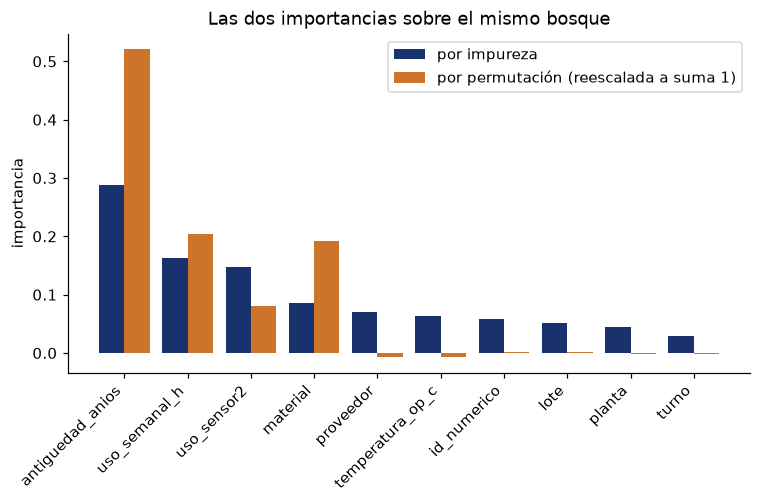

In [24]:
tabla = pd.DataFrame({"impureza": vi_imp, "permutación": vi_perm / vi_perm.clip(lower=0).sum()})
tabla = tabla.sort_values("impureza", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
pos = np.arange(len(tabla))
ax.bar(pos - 0.2, tabla["impureza"], width=0.4, color=AZUL, label="por impureza")
ax.bar(pos + 0.2, tabla["permutación"], width=0.4, color=NARANJA, label="por permutación (reescalada a suma 1)")
ax.set_xticks(pos)
ax.set_xticklabels(tabla.index, rotation=45, ha="right")
ax.set_ylabel("importancia")
ax.set_title("Las dos importancias sobre el mismo bosque")
ax.legend()
plt.show()

### El reajuste sin el feature

Ninguna de las dos importancias responde a la pregunta *¿el bosque necesita este
feature?* La única medida que la responde es ajustar el bosque **sin** el feature y medir
el error. Cuesta un bosque por feature, y por eso se la reserva para los que importan.

In [25]:
def error_sin(feature: str) -> float:
    columnas = [c for c in X_ext.columns if GRUPO[c] != feature]
    b = RandomForestClassifier(n_estimators=B, max_features="sqrt",
                               random_state=SEMILLA, n_jobs=-1).fit(X_ext_ajuste[columnas], y_ajuste)
    return error(b.predict(X_ext_prueba[columnas]), y_prueba)


candidatos = ["antiguedad_anios", "uso_semanal_h", "uso_sensor2", "material", "planta",
              "id_numerico", "proveedor", "temperatura_op_c"]
reajuste = pd.Series({f: error_sin(f) for f in candidatos})

resumen = pd.DataFrame({"impureza": vi_imp[candidatos], "permutación": vi_perm[candidatos],
                        "error sin el feature": reajuste})
print(f"bosque completo, error de prueba: {err_bosque:.4f}   (resolucion +/- 0.014)\n")
print(resumen.round(4).to_string())

bosque completo, error de prueba: 0.0917   (resolucion +/- 0.014)

                  impureza  permutación  error sin el feature
antiguedad_anios    0.2877       0.2553                0.2917
uso_semanal_h       0.1633       0.1000                0.0944
uso_sensor2         0.1469       0.0394                0.0778
material            0.0858       0.0939                0.2056
planta              0.0445      -0.0008                0.0889
id_numerico         0.0587       0.0006                0.0917
proveedor           0.0703      -0.0036                0.0861
temperatura_op_c    0.0627      -0.0031                0.0861


### Para analizar

1. `uso_sensor2` recibe por impureza casi tanto crédito como `uso_semanal_h`, por
   permutación una fracción de eso, y el bosque sin él tiene el mismo error, o menor. ¿Qué mecanismo produce el primer número, y
   por qué el segundo no lo corrige del todo (mirar `uso_semanal_h`)?
2. `id_numerico`, `proveedor` y `planta` reciben crédito por impureza del mismo orden, y por
   permutación los tres dan cero; el reajuste sin cualquiera de ellos no mueve el error.
   Pero `planta` **sí** interviene en la regla que generó los datos, y los otros dos no.
   ¿Qué mide entonces cada una de las tres columnas, y cuál de las tres habla del problema?
3. Quitar `antiguedad_anios` multiplica el error por más de tres; quitar `uso_semanal_h`
   apenas lo mueve, aunque la verdad del dataset parte sobre él dos veces. ¿Por qué, y
   qué dice eso sobre leer una importancia como "cuánto vale este feature en el problema"?

**Respuesta:**

1. `uso_sensor2` está casi perfectamente correlacionado con `uso_semanal_h`. Cuando la
   variable original no entra entre los candidatos de un split, el proxy puede ocupar su
   lugar y recibir reducción de impureza, por eso ambos acumulan crédito. La permutación
   tampoco elimina del todo este reparto: al romper una variable, la otra sigue llevando
   casi la misma información y amortigua el aumento del error. La asimetría (`0.1000`
   para `uso_semanal_h` y `0.0394` para `uso_sensor2`) indica que el bosque ajustado se
   apoyó más en la original, pero ninguna cifra es un valor intrínseco del feature. El
   reajuste confirma la redundancia: sin el sensor 2 el error incluso baja de `0.0917` a
   `0.0778`.
2. La importancia por impureza mide cuánto usó el bosque cada variable para reducir
   impureza sobre ajuste, con sesgo hacia variables de alta cardinalidad y splits
   accidentales. La permutación mide cuánto dependen las predicciones de ese bosque ya
   ajustado de una columna, dadas las demás; puede ser cero por redundancia o porque el
   bosque no la aprovechó. El reajuste sin el feature mide su valor predictivo incremental
   dentro del problema y del conjunto de variables disponible. De las tres, esta última
   es la que habla directamente de si el problema predictivo necesita el feature, aunque
   tampoco identifica por sí sola la regla causal o generadora. Aquí muestra que ni
   `id_numerico`, ni `proveedor`, ni `planta` son necesarios para mantener el error, aun
   cuando solo `planta` pertenece a la regla verdadera.
3. `antiguedad_anios` contiene señal fuerte que las demás variables no reemplazan; al
   quitarla, el error pasa de `0.0917` a `0.2917`. En cambio, al quitar
   `uso_semanal_h`, `uso_sensor2` conserva casi la misma información y el error queda en
   `0.0944`. Por eso una importancia no significa «cuánto vale el feature en el problema»
   de forma absoluta: depende de las variables redundantes disponibles, de cómo el modelo
   repartió el uso entre ellas y de la distribución sobre la que se evalúa.


      árbol (cv)     oob  prueba
1.0       0.2238  0.2238  0.1944
2.0       0.1821  0.1810  0.1972
3.0       0.0845  0.0845  0.0778
4.0       0.0976  0.0810  0.0806
5.0       0.1071  0.0845  0.0750
6.0       0.1226  0.0869  0.0750
8.0       0.1405  0.0869  0.0778
12.0      0.1595  0.0857  0.0778
NaN       0.1548  0.0869  0.0778


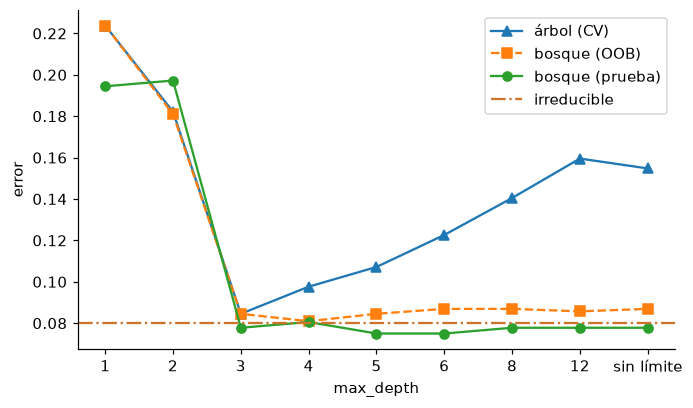

In [ ]:
# MAX DEPTH EJ EXTRA

valores_profundidad = [1, 2, 3, 4, 5, 6, 8, 12, None]

curva_profundidad_arbol = pd.Series(
    [
        1.0 - cross_val_score(
            DecisionTreeClassifier(max_depth=d, random_state=SEMILLA),
            X_ajuste,
            y_ajuste,
            cv=folds,
        ).mean()
        for d in valores_profundidad
    ],
    index=valores_profundidad,
    name="árbol (cv)",
)

curva_profundidad_bosque = barrido("max_depth", valores_profundidad)

resultado_profundidad = pd.concat(
    [curva_profundidad_arbol, curva_profundidad_bosque], axis=1
)
print(resultado_profundidad.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(valores_profundidad))
ax.plot(x, resultado_profundidad["árbol (cv)"], "^-", label="árbol (CV)")
ax.plot(x, resultado_profundidad["oob"], "s--", label="bosque (OOB)")
ax.plot(x, resultado_profundidad["prueba"], "o-", label="bosque (prueba)")
ax.axhline(0.08, color=NARANJA, ls="-.", label="irreducible")
ax.set_xticks(x)
ax.set_xticklabels(["sin límite" if d is None else d for d in valores_profundidad])
ax.set_xlabel("max_depth")
ax.set_ylabel("error")
ax.legend()
plt.show()

**Analisis**

La regla generadora tiene profundidad 3, por lo que un árbol con `max_depth=3` ya puede
representarla completamente. Su error de validación es `0.0845`, aproximadamente el
error irreducible de `0.08`. Con profundidad 1 o 2 el árbol no puede representar todas
las interacciones y tiene sesgo; por encima de 3 empieza a ajustar el ruido de las
etiquetas y aumenta su varianza.

En el bosque, desde profundidad 3 en adelante todos los resultados empatan dentro de la
resolución: el promedio controla la varianza de los árboles profundos. En un problema
real no conoceríamos de antemano la profundidad de la regla verdadera. Habría que
seleccionarla usando validación cruzada u OOB; elegir 3 directamente requeriría conocer
la estructura generadora, algo que normalmente no está disponible.

In [28]:
def comparar_votos(B_actual: int) -> dict:
    modelo = BaggingClassifier(
        DecisionTreeClassifier(
            min_samples_leaf=5,
            random_state=SEMILLA,
        ),
        n_estimators=B_actual,
        random_state=SEMILLA,
        n_jobs=-1,
    ).fit(X_ajuste, y_ajuste)

    # Scikit-learn promedia las probabilidades de las hojas.
    pred_blando = modelo.predict(X_prueba)

    # El voto duro cuenta solamente la clase elegida por cada árbol.
    X_np = X_prueba.to_numpy()
    votos = np.array([
        estimador.predict(X_np[:, columnas])
        for estimador, columnas in zip(
            modelo.estimators_, modelo.estimators_features_
        )
    ])
    pred_duro = (votos.mean(axis=0) >= 0.5).astype(int)

    return {
        "B": B_actual,
        "desacuerdo": (pred_blando != pred_duro).mean(),
        "error blando": error(pred_blando, y_prueba),
        "error duro": error(pred_duro, y_prueba),
    }

comparacion_votos = pd.DataFrame([
    comparar_votos(5),
    comparar_votos(200),
]).set_index("B")

print(comparacion_votos.round(4).to_string())

     desacuerdo  error blando  error duro
B                                        
5        0.0056        0.0917      0.0972
200      0.0000        0.0889      0.0889


**Análisis:**

Con hojas no puras, un árbol puede votar clase 1 con una proporción de hoja apenas mayor
que 0,5 y otro puede votar clase 0 con mucha seguridad. El voto duro les asigna el mismo
peso, mientras que el blando conserva esas intensidades. Con solo cinco árboles esto
cambia la decisión en el 0,56 % de la prueba. Con 200 árboles los dos procedimientos
coinciden en este conjunto: el promedio se estabiliza y los pocos desacuerdos dejan de
alcanzar para cruzar el umbral.

In [29]:
from time import perf_counter
from sklearn.ensemble import ExtraTreesClassifier


def medir_modelo(clase, repeticiones: int = 5) -> dict:
    tiempos = []
    errores = []

    for _ in range(repeticiones):
        modelo = clase(
            n_estimators=B,
            max_features="sqrt",
            random_state=SEMILLA,
            n_jobs=-1,
        )
        inicio = perf_counter()
        modelo.fit(X_ajuste, y_ajuste)
        tiempos.append(perf_counter() - inicio)
        errores.append(error(modelo.predict(X_prueba), y_prueba))

    return {
        "modelo": clase.__name__,
        "tiempo mediano (s)": np.median(tiempos),
        "error": np.mean(errores),
    }


comparacion_extra = pd.DataFrame([
    medir_modelo(RandomForestClassifier),
    medir_modelo(ExtraTreesClassifier),
]).set_index("modelo")

print(comparacion_extra.round(4).to_string())

                        tiempo mediano (s)   error
modelo                                            
RandomForestClassifier              0.1208  0.0833
ExtraTreesClassifier                0.0900  0.1806


**Análisis:**

Extra-Trees fue aproximadamente un 25 % más rápido, porque no busca exhaustivamente el
mejor umbral: prueba umbrales aleatorios. Sin embargo, su error fue mucho mayor (`0.1806`
contra `0.0833`). En este problema hay pocos features informativos y una regla con cortes
precisos; combinar selección de pocos features con umbrales aleatorios hace que muchos
splits sean débiles. La aleatoriedad adicional reduce correlación y tiempo, pero aquí
aumenta demasiado el sesgo.

 x  lineal  bosque
 5   9.970   9.311
10  19.979  19.802
25  50.007  19.802


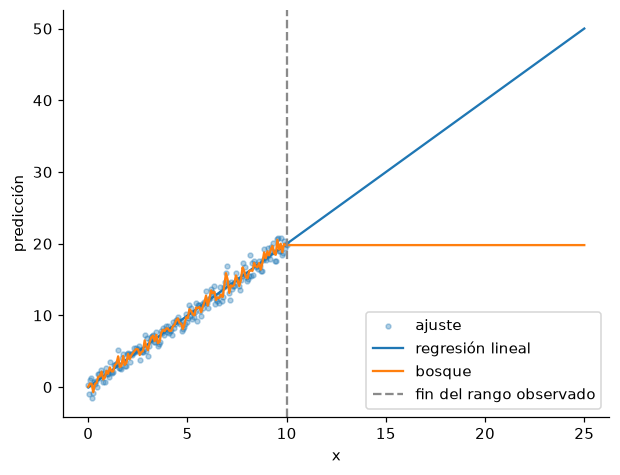

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(SEMILLA)
x = np.linspace(0, 10, 200)
y = 2 * x + rng.normal(0, 1, len(x))
X = x.reshape(-1, 1)

lineal = LinearRegression().fit(X, y)
bosque_reg = RandomForestRegressor(
    n_estimators=B,
    random_state=SEMILLA,
    n_jobs=-1,
).fit(X, y)

puntos = np.array([5, 10, 25]).reshape(-1, 1)
comparacion_extrapolacion = pd.DataFrame({
    "x": puntos.ravel(),
    "lineal": lineal.predict(puntos),
    "bosque": bosque_reg.predict(puntos),
})
print(comparacion_extrapolacion.round(3).to_string(index=False))

x_grafico = np.linspace(0, 25, 300).reshape(-1, 1)
plt.scatter(x, y, s=10, alpha=0.35, label="ajuste")
plt.plot(x_grafico, lineal.predict(x_grafico), label="regresión lineal")
plt.plot(x_grafico, bosque_reg.predict(x_grafico), label="bosque")
plt.axvline(10, color=GRIS, ls="--", label="fin del rango observado")
plt.xlabel("x")
plt.ylabel("predicción")
plt.legend()
plt.show()

**Análisis:**

La regresión lineal aprendió una pendiente cercana a 2 y prolonga esa relación hasta
$x=25$, donde predice aproximadamente 50. El bosque solo puede asignar la observación a
hojas construidas dentro del rango observado $[0,10]$; por eso su predicción queda cerca
del valor del extremo, alrededor de 19,8.

Con deriva, una variable puede salir del rango histórico y el bosque seguir devolviendo
valores aparentemente razonables pero saturados en los extremos. El modelo no advierte
que está extrapolando. Esto exige monitorear la distribución de entrada y definir qué
hacer ante observaciones fuera de rango.

In [31]:
def importancia_permutacion_grupo(
    modelo,
    X: pd.DataFrame,
    y: np.ndarray,
    columnas: list[str],
    rng: np.random.Generator,
    r: int = 50,
) -> tuple[float, float]:
    """Permuta conjuntamente todas las columnas usando el mismo orden de filas."""
    error_base = error(modelo.predict(X), y)
    aumentos = []

    for _ in range(r):
        orden = rng.permutation(len(X))
        X_permutado = X.copy()
        X_permutado[columnas] = X[columnas].iloc[orden].to_numpy()
        aumentos.append(
            error(modelo.predict(X_permutado), y) - error_base
        )

    return float(np.mean(aumentos)), float(np.std(aumentos))


columnas_proveedor = [
    c for c in X_ext_prueba.columns
    if GRUPO[c] == "proveedor"
]

media_grupo, desvio_grupo = importancia_permutacion_grupo(
    bosque,
    X_ext_prueba,
    y_prueba,
    columnas_proveedor,
    np.random.default_rng(SEMILLA),
)

print(f"columnas one-hot de proveedor : {len(columnas_proveedor)}")
print(f"permutación conjunta          : {media_grupo:.4f} +/- {desvio_grupo:.4f}")
print(f"suma columna por columna      : {vi_perm['proveedor']:.4f}")

columnas one-hot de proveedor : 12
permutación conjunta          : -0.0027 +/- 0.0016
suma columna por columna      : -0.0036


**Análisis:**

Ambas medidas son esencialmente cero: `proveedor` es ruido y romperlo no perjudica al
bosque. La diferencia conceptual es importante. Permutar cada dummy de forma independiente
puede crear filas imposibles, por ejemplo ninguna categoría activa o varias activas al
mismo tiempo. La permutación conjunta conserva una categoría válida por fila y rompe la
relación del feature completo con la respuesta. Para una variable categórica codificada
one-hot, la medida conjunta es la interpretación más correcta.

In [32]:
from sklearn.preprocessing import StandardScaler

bosque_proximidad = RandomForestClassifier(
    n_estimators=B,
    max_features="sqrt",
    random_state=SEMILLA,
    n_jobs=-1,
).fit(X_ajuste, y_ajuste)

# Recupera los índices originales en el mismo orden de la partición del laboratorio.
idx_ajuste, idx_prueba, _, _ = train_test_split(
    np.arange(len(datos)),
    y_todo,
    test_size=0.30,
    random_state=SEMILLA,
    stratify=y_todo,
)

# Se toma como consulta la primera máquina del conjunto de prueba.
q = 0
hojas_ajuste = bosque_proximidad.apply(X_ajuste)
hojas_consulta = bosque_proximidad.apply(X_prueba.iloc[[q]])[0]
proximidad = (hojas_ajuste == hojas_consulta).mean(axis=1)
vecinos_bosque = np.argsort(-proximidad)[:10]

# Comparación con distancia euclidiana sobre columnas estandarizadas.
escalador = StandardScaler().fit(X_ajuste)
Z_ajuste = escalador.transform(X_ajuste)
z_consulta = escalador.transform(X_prueba.iloc[[q]])[0]
distancia = np.linalg.norm(Z_ajuste - z_consulta, axis=1)
vecinos_euclideos = np.argsort(distancia)[:10]


def tabla_vecinos(indices: np.ndarray) -> pd.DataFrame:
    return pd.DataFrame({
        "id_maquina": datos.iloc[idx_ajuste[indices]]["id_maquina"].to_numpy(),
        "respuesta": y_ajuste[indices],
        "proximidad": proximidad[indices],
        "distancia_euclidiana": distancia[indices],
    })


print(
    "consulta:",
    datos.iloc[idx_prueba[q]]["id_maquina"],
    "respuesta:",
    y_prueba[q],
)
print("\nVecinos por proximidad del bosque:")
print(tabla_vecinos(vecinos_bosque).round(3).to_string(index=False))
print("\nVecinos por distancia euclidiana:")
print(tabla_vecinos(vecinos_euclideos).round(3).to_string(index=False))
print(
    "\nVecinos compartidos:",
    len(set(vecinos_bosque) & set(vecinos_euclideos)),
    "de 10",
)

consulta: MQ-0139 respuesta: 0

Vecinos por proximidad del bosque:
id_maquina  respuesta  proximidad  distancia_euclidiana
   MQ-0963          0       0.365                 6.318
   MQ-0411          0       0.305                 5.739
   MQ-0034          0       0.245                 3.806
   MQ-0235          0       0.225                 6.080
   MQ-0788          0       0.220                 6.819
   MQ-1151          0       0.215                 4.744
   MQ-1157          0       0.215                 4.792
   MQ-0951          0       0.215                 6.333
   MQ-0530          0       0.205                 6.484
   MQ-1013          0       0.200                 6.247

Vecinos por distancia euclidiana:
id_maquina  respuesta  proximidad  distancia_euclidiana
   MQ-0034          0       0.245                 3.806
   MQ-1083          0       0.065                 4.238
   MQ-0665          0       0.100                 4.611
   MQ-0663          1       0.030                 4.711
  

**Análisis:**

Para la máquina de consulta `MQ-0139`, solo 3 de los 10 vecinos aparecen en ambas
listas. Los diez vecinos elegidos por el bosque tienen respuesta 0, igual que la consulta;
entre los vecinos euclidianos aparece una máquina con respuesta 1.

La distancia euclidiana busca cercanía geométrica después de estandarizar las columnas,
sin utilizar la respuesta. La proximidad del bosque cuenta con qué frecuencia dos
observaciones terminan en la misma hoja. Por lo tanto, aprende una noción de similitud
supervisada: dos máquinas pueden estar lejos geométricamente, pero resultar próximas si
el bosque las considera equivalentes para predecir la inspección. Esta proximidad depende
del bosque ajustado y no constituye una distancia euclidiana ni necesariamente satisface
todas las propiedades de una métrica.